# **Sisfall Dataset Exploration**

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

## Sisfall Description
* Data were acquired with three sensors (2 accelerometers and 1 gyroscope) at a frequency sample of 200 Hz.
* The motion sensor is simply placed on the waist.
* 19 ADLs types & 15 Falls Types
* The SUBJECT_ID depends of the age of the subjects:

    * SA: Adults subjects between 19 and 30 years old
    * SE: Elderly people between 60 and 75 years old
* The Sisfall dataset is available here https://github.com/BIng2325/SisFall/releases

In [7]:
root = "sisfall"

all_data = []
metadata = []

for subject in os.listdir(root):

    subject_path = os.path.join(root, subject)

    if os.path.isdir(subject_path):

        for file in os.listdir(subject_path):

            if file.endswith(".txt"):

                path = os.path.join(subject_path, file)

                df = pd.read_csv(path, header=None)

                df.columns = [
                    "acc1_x","acc1_y","acc1_z",
                    "gyro_x","gyro_y","gyro_z",
                    "acc2_x","acc2_y","acc2_z"
                ]

                activity = file.split("_")[0]
                trial = file.split("_")[2].replace(".txt","")

                df["subject"] = subject
                df["activity"] = activity
                df["trial"] = trial
                df["type"] = "Fall" if activity.startswith("F") else "ADL"
                df["age_group"] = "Adult" if subject.startswith("SA") else "Elderly"

                all_data.append(df)

                metadata.append({
                    "subject": subject,
                    "activity": activity,
                    "trial": trial,
                    "type": "Fall" if activity.startswith("F") else "ADL",
                    "age_group": "Adult" if subject.startswith("SA") else "Elderly",
                    "length": len(df)
                })

data = pd.concat(all_data, ignore_index=True)
meta = pd.DataFrame(metadata)

In [8]:
print(meta.head())
print("Total samples:", len(data))
print("Total activities:", len(meta))

  subject activity trial type age_group  length
0    SA01      D01   R01  ADL     Adult   19999
1    SA01      D02   R01  ADL     Adult   20000
2    SA01      D03   R01  ADL     Adult   20000
3    SA01      D04   R01  ADL     Adult   20000
4    SA01      D05   R01  ADL     Adult    5000
Total samples: 15858929
Total activities: 4505


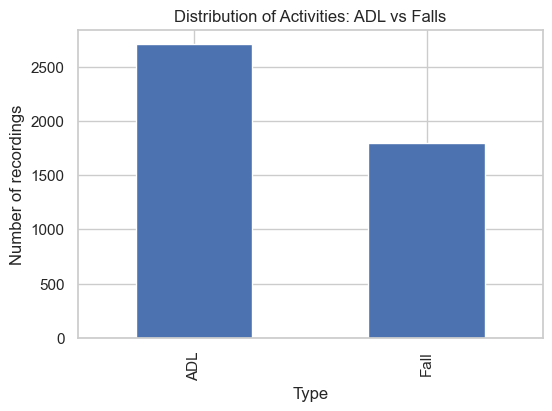

In [9]:
plt.figure(figsize=(6,4))

meta["type"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Activities: ADL vs Falls")
plt.xlabel("Type")
plt.ylabel("Number of recordings")
plt.show()

In [ ]:
type_counts = meta["type"].value_counts()
type_percentage = (type_counts / type_counts.sum() * 100).round(2)

print(f"\nADL vs Fall Distribution:")
print(type_percentage)


ADL vs Fall Distribution:
type
ADL     60.09
Fall    39.91
Name: count, dtype: float64


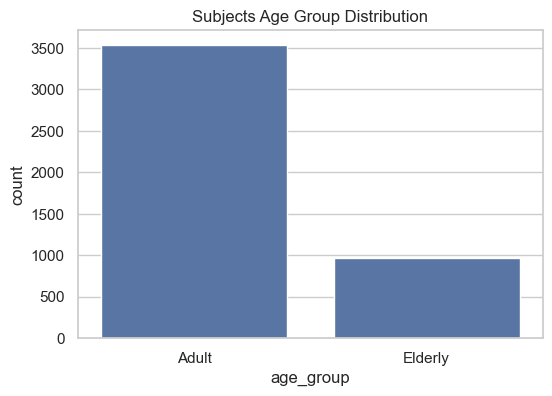

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=meta,
    x="age_group"
)

plt.title("Subjects Age Group Distribution")
plt.show()

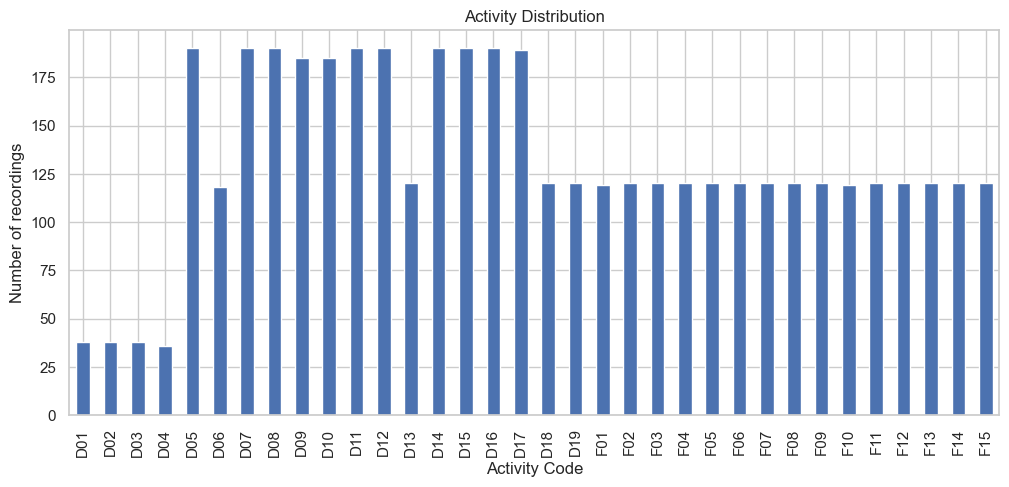

In [11]:
plt.figure(figsize=(12,5))

meta["activity"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Activity Distribution")
plt.xlabel("Activity Code")
plt.ylabel("Number of recordings")

plt.show()

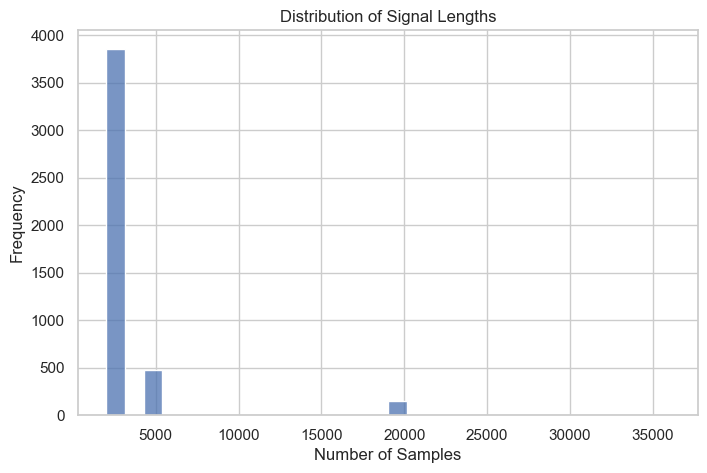

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(meta["length"], bins=30)

plt.title("Distribution of Signal Lengths")
plt.xlabel("Number of Samples")
plt.ylabel("Frequency")

plt.show()

In [13]:
scale = (2*16)/(2**13)

data["acc_x_g"] = data["acc1_x"] * scale
data["acc_y_g"] = data["acc1_y"] * scale
data["acc_z_g"] = data["acc1_z"] * scale

In [14]:
data["acc_mag"] = np.sqrt(
    data["acc1_x"]**2 +
    data["acc1_y"]**2 +
    data["acc1_z"]**2
)

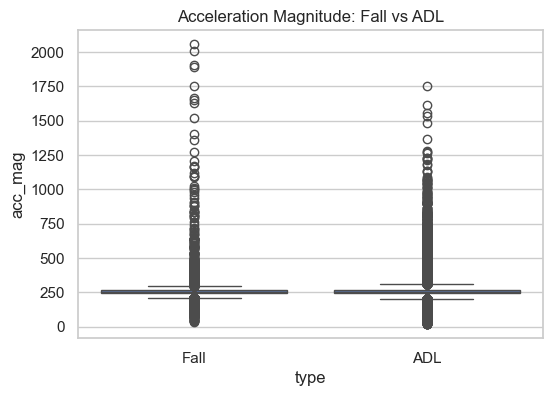

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=data.sample(20000),
    x="type",
    y="acc_mag"
)

plt.title("Acceleration Magnitude: Fall vs ADL")

plt.show()

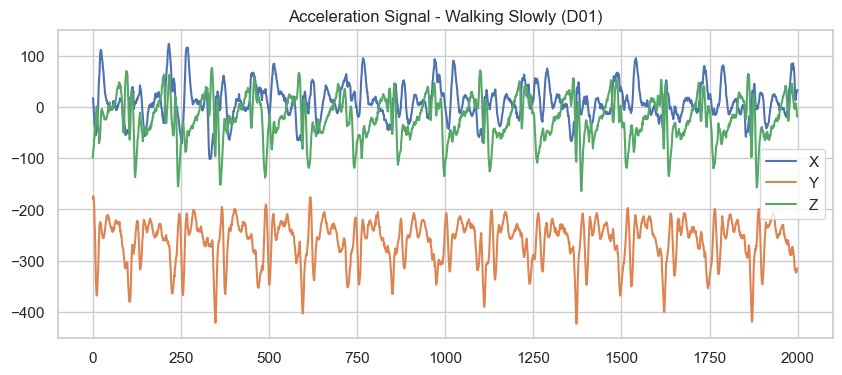

In [16]:
sample_adl = data[data["activity"]=="D01"].iloc[:2000]

plt.figure(figsize=(10,4))

plt.plot(sample_adl["acc1_x"], label="X")
plt.plot(sample_adl["acc1_y"], label="Y")
plt.plot(sample_adl["acc1_z"], label="Z")

plt.title("Acceleration Signal - Walking Slowly (D01)")
plt.legend()

plt.show()

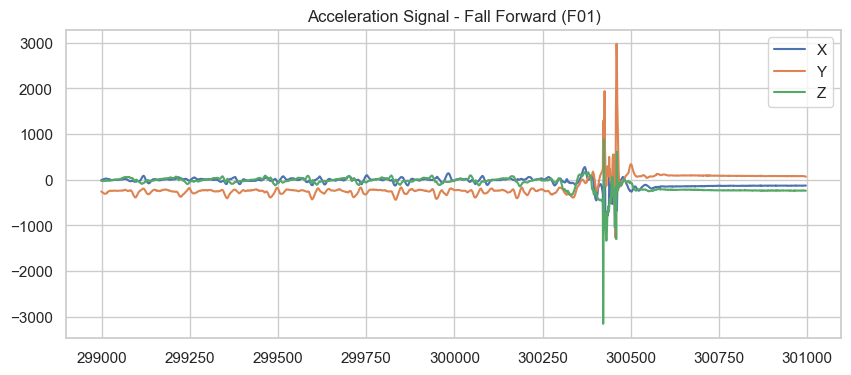

In [17]:
sample_fall = data[data["activity"]=="F01"].iloc[:2000]

plt.figure(figsize=(10,4))

plt.plot(sample_fall["acc1_x"], label="X")
plt.plot(sample_fall["acc1_y"], label="Y")
plt.plot(sample_fall["acc1_z"], label="Z")

plt.title("Acceleration Signal - Fall Forward (F01)")
plt.legend()

plt.show()

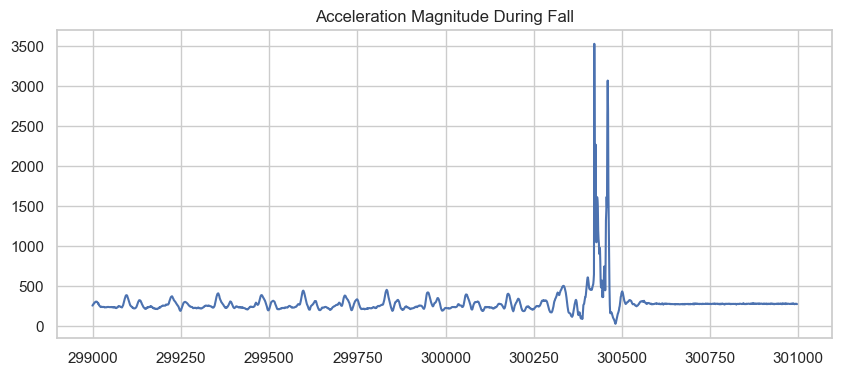

In [18]:
plt.figure(figsize=(10,4))

plt.plot(sample_fall["acc_mag"])

plt.title("Acceleration Magnitude During Fall")

plt.show()

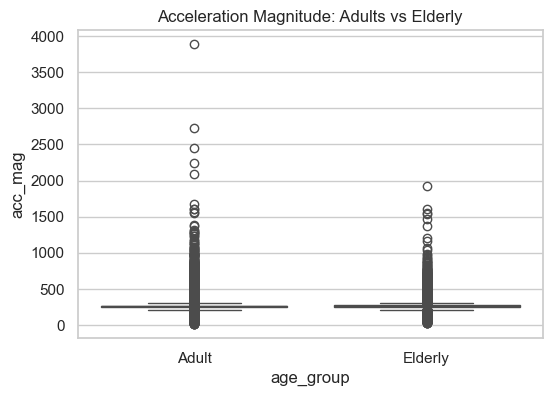

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=data.sample(20000),
    x="age_group",
    y="acc_mag"
)

plt.title("Acceleration Magnitude: Adults vs Elderly")

plt.show()

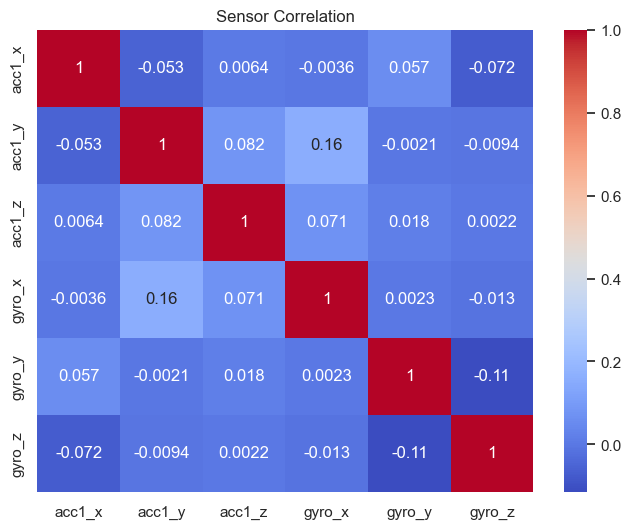

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data[[
        "acc1_x","acc1_y","acc1_z",
        "gyro_x","gyro_y","gyro_z"
    ]].corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Sensor Correlation")

plt.show()

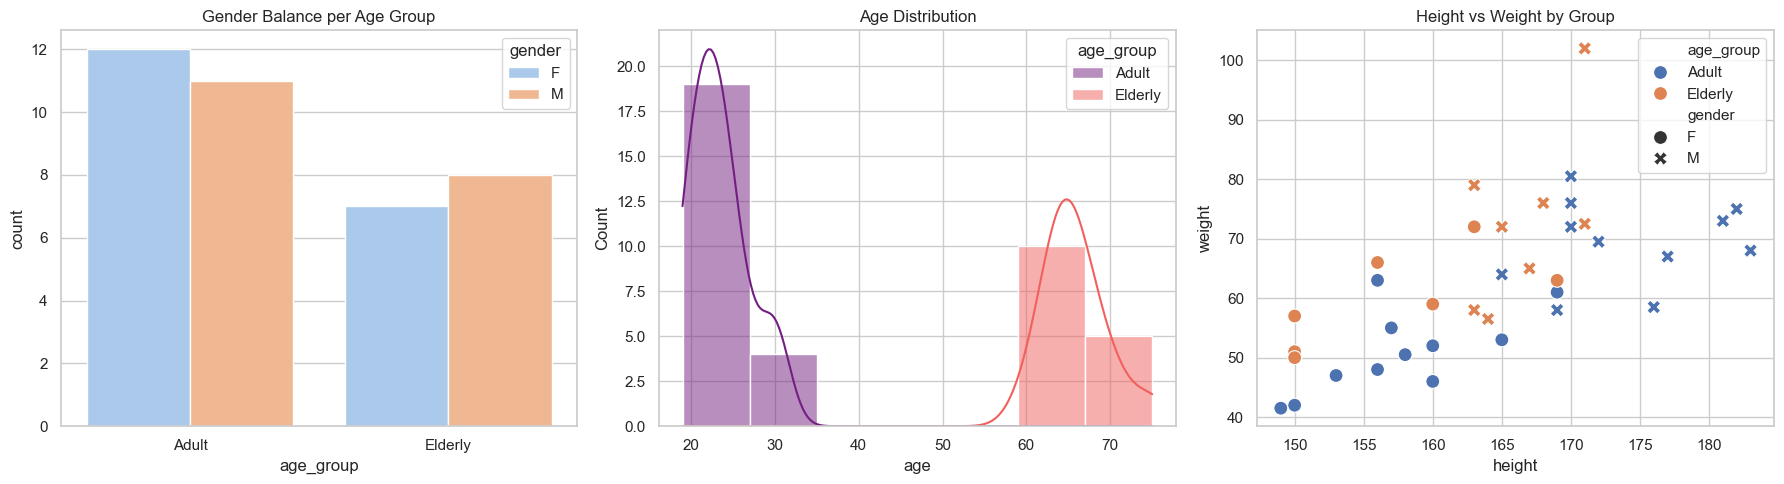

In [21]:
meta = pd.DataFrame(metadata)

subjects_info = [
    ["SA01", 26, 165, 53, "F"], ["SA02", 23, 176, 58.5, "M"], ["SA03", 19, 156, 48, "F"],
    ["SA04", 23, 170, 72, "M"], ["SA05", 22, 172, 69.5, "M"], ["SA06", 21, 169, 58, "M"],
    ["SA07", 21, 156, 63, "F"], ["SA08", 21, 149, 41.5, "F"], ["SA09", 24, 165, 64, "M"],
    ["SA10", 21, 177, 67, "M"], ["SA11", 19, 170, 80.5, "M"], ["SA12", 25, 153, 47, "F"],
    ["SA13", 22, 157, 55, "F"], ["SA14", 27, 160, 46, "F"], ["SA15", 25, 160, 52, "F"],
    ["SA16", 20, 169, 61, "F"], ["SA17", 23, 182, 75, "M"], ["SA18", 23, 181, 73, "M"],
    ["SA19", 30, 170, 76, "M"], ["SA20", 30, 150, 42, "F"], ["SA21", 30, 183, 68, "M"],
    ["SA22", 19, 158, 50.5, "F"], ["SA23", 24, 156, 48, "F"], ["SE01", 71, 171, 102, "M"],
    ["SE02", 75, 150, 57, "F"], ["SE03", 62, 150, 51, "F"], ["SE04", 63, 160, 59, "F"],
    ["SE05", 63, 165, 72, "M"], ["SE06", 60, 163, 79, "M"], ["SE07", 65, 168, 76, "M"],
    ["SE08", 68, 163, 72, "F"], ["SE09", 66, 167, 65, "M"], ["SE10", 64, 156, 66, "F"],
    ["SE11", 66, 169, 63, "F"], ["SE12", 69, 164, 56.5, "M"], ["SE13", 65, 171, 72.5, "M"],
    ["SE14", 67, 163, 58, "M"], ["SE15", 64, 150, 50, "F"]
]

df_subjects = pd.DataFrame(subjects_info, columns=["subject", "age", "height", "weight", "gender"])
df_subjects["age_group"] = df_subjects["subject"].apply(lambda x: "Adult" if x.startswith("SA") else "Elderly")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Distribuição por Género e Grupo
sns.countplot(data=df_subjects, x="age_group", hue="gender", ax=axes[0], palette="pastel")
axes[0].set_title("Gender Balance per Age Group")

# B. Distribuição de Idades
sns.histplot(data=df_subjects, x="age", hue="age_group", kde=True, ax=axes[1], palette="magma")
axes[1].set_title("Age Distribution")

# C. Relação Peso vs Altura
sns.scatterplot(data=df_subjects, x="height", y="weight", hue="age_group", style="gender", s=100, ax=axes[2])
axes[2].set_title("Height vs Weight by Group")

plt.tight_layout()
plt.show()

C:\Users\leono\AppData\Local\Temp\ipykernel_25132\2410386249.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=meta_full, x="type", palette="viridis")


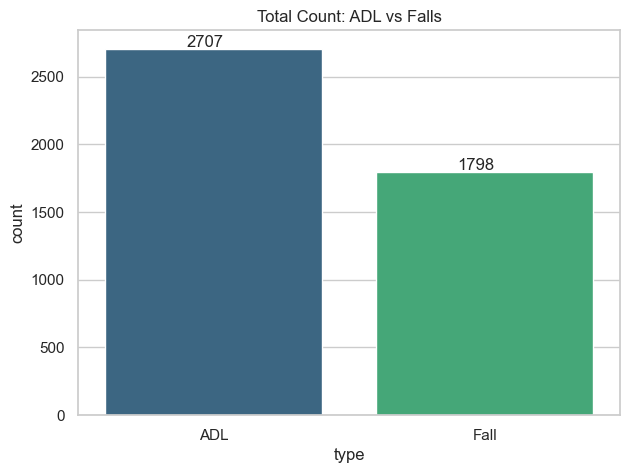

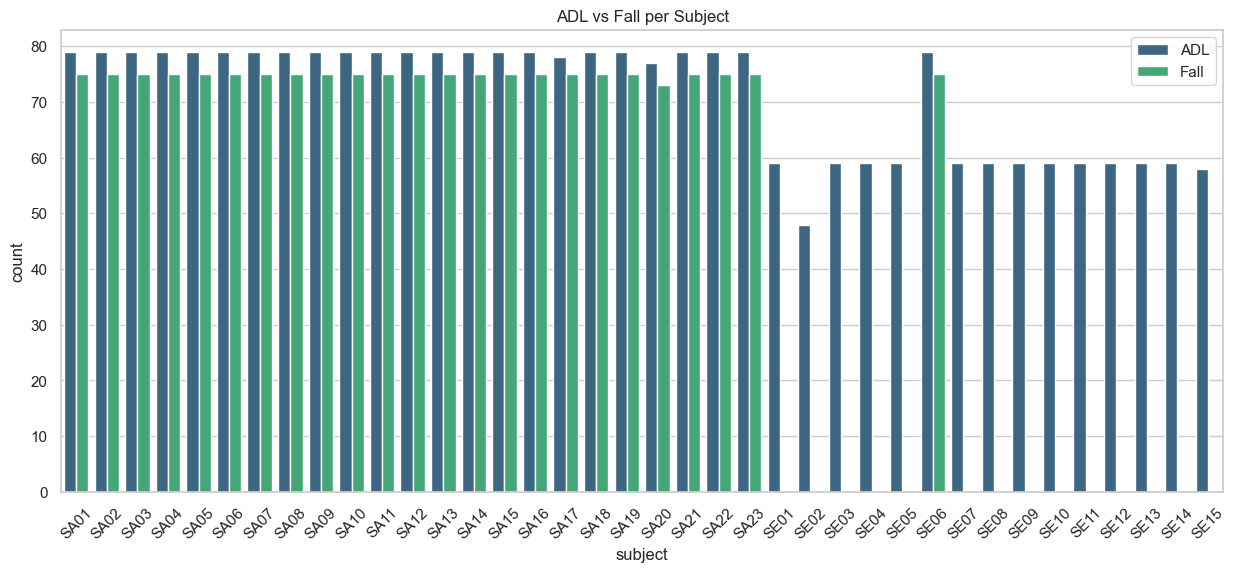

C:\Users\leono\AppData\Local\Temp\ipykernel_25132\2410386249.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_falls_only, x="activity", palette="Reds_r",


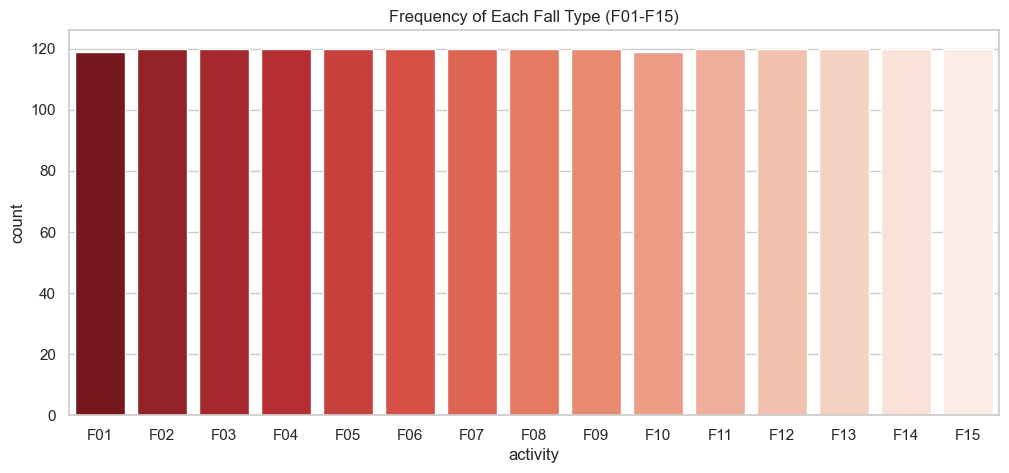

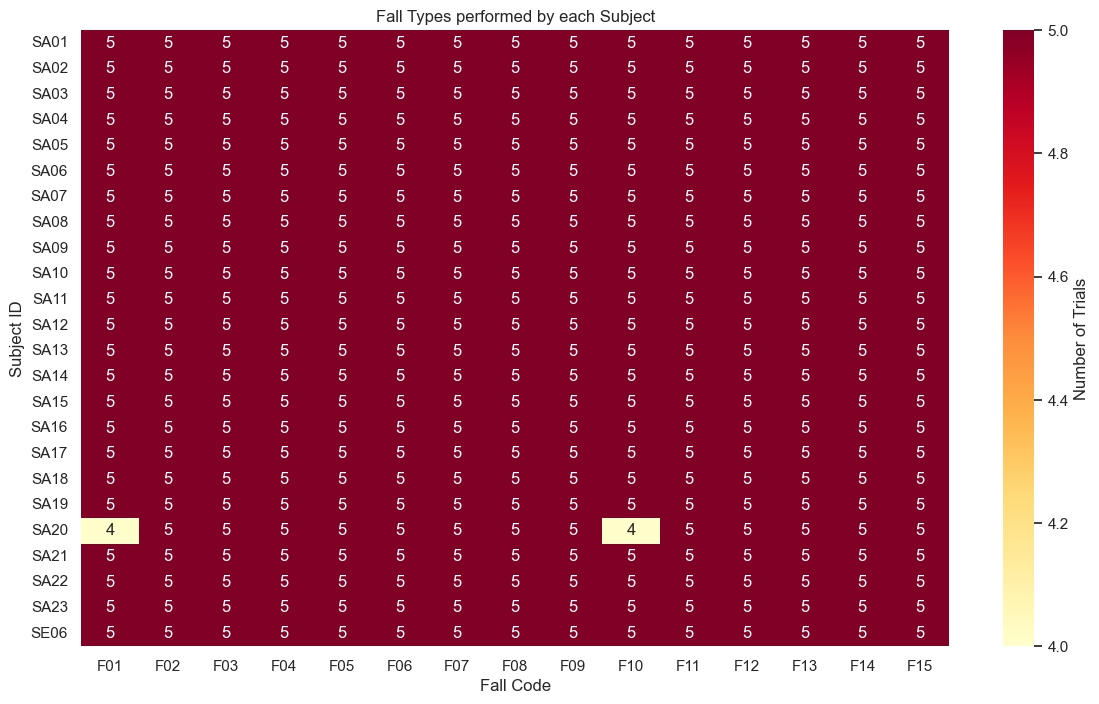

In [22]:
meta_full = pd.merge(meta, df_subjects, on="subject", how="left")

# 1. ADL vs Fall (Geral)
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=meta_full, x="type", palette="viridis")
plt.title("Total Count: ADL vs Falls")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+10))
plt.show()

# 2. ADL vs Fall (Per Subject)
# Nota: Verás que quase todos os SE não têm Falls (exceto SE06)
plt.figure(figsize=(15, 6))
sns.countplot(data=meta_full, x="subject", hue="type", palette="viridis")
plt.title("ADL vs Fall per Subject")
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.show()

# 3. Tipos de Queda (Geral) - Apenas códigos 'F'
df_falls_only = meta_full[meta_full["type"] == "Fall"].copy()

plt.figure(figsize=(12, 5))
sns.countplot(data=df_falls_only, x="activity", palette="Reds_r", 
              order=[f"F{i:02d}" for i in range(1, 16)])
plt.title("Frequency of Each Fall Type (F01-F15)")
plt.show()

# 4. Tipos de Queda per Subject (Heatmap)
# Mostra se todos os sujeitos fizeram todos os tipos de queda
fall_matrix = df_falls_only.groupby(["subject", "activity"]).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(fall_matrix, annot=True, cmap="YlOrRd", cbar_kws={'label': 'Number of Trials'})
plt.title("Fall Types performed by each Subject")
plt.xlabel("Fall Code")
plt.ylabel("Subject ID")
plt.show()

C:\Users\leono\AppData\Local\Temp\ipykernel_25132\3860966120.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sisfall_samples, x='subject', y='percentage', palette='viridis')


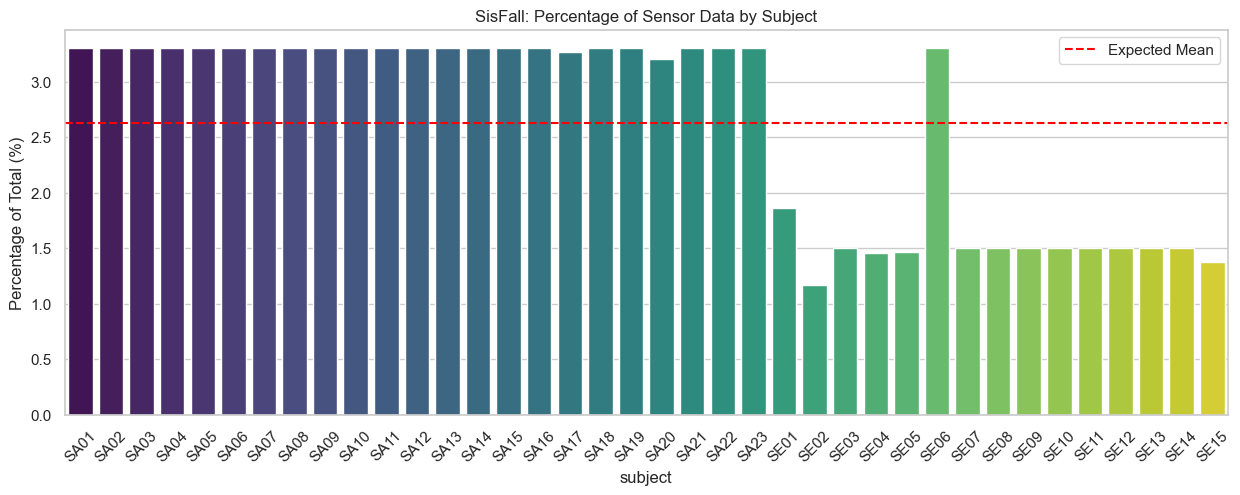

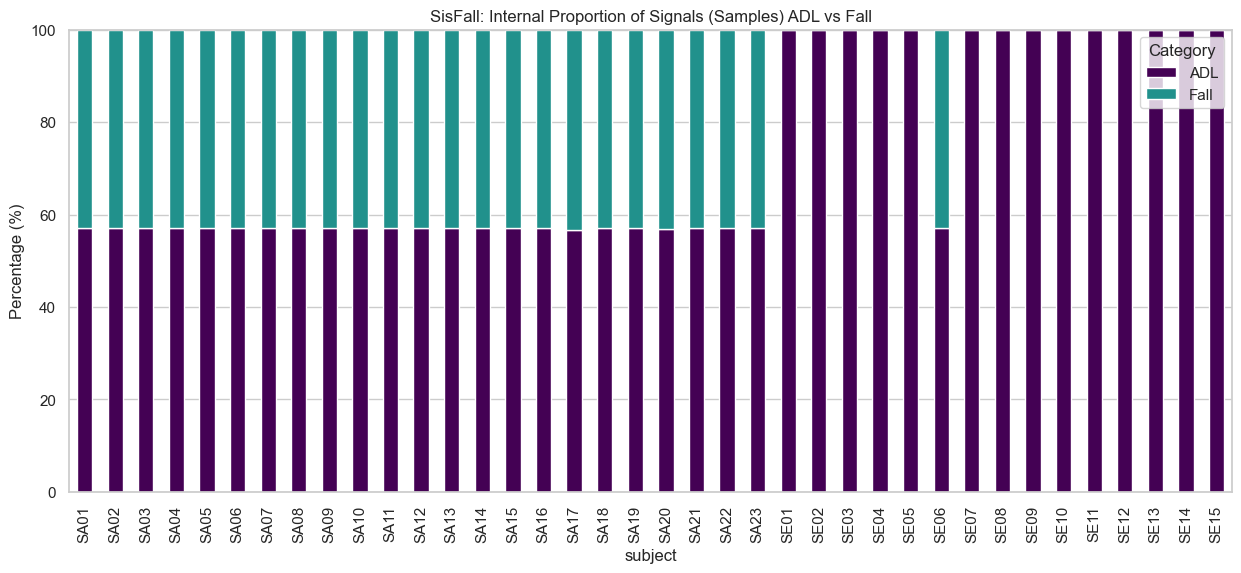

In [27]:
sisfall_samples = meta.groupby('subject')['length'].sum().reset_index()
total_samples_sisfall = sisfall_samples['length'].sum()
sisfall_samples['percentage'] = (sisfall_samples['length'] / total_samples_sisfall) * 100


plt.figure(figsize=(15, 5))
ax = sns.barplot(data=sisfall_samples, x='subject', y='percentage', palette='viridis')
plt.axhline(100/len(sisfall_samples), color='red', linestyle='--', label='Expected Mean')
plt.title("SisFall: Percentage of Sensor Data by Subject")
plt.ylabel("Percentage of Total (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()


sisfall_prop = meta.groupby(['subject', 'type'])['length'].sum().unstack(fill_value=0)
sisfall_prop_norm = sisfall_prop.div(sisfall_prop.sum(axis=1), axis=0) * 100

sisfall_prop_norm.plot(kind='bar', stacked=True, figsize=(15, 6), color=['#440154', '#21918c'])
plt.title("SisFall: Internal Proportion of Signals (Samples) ADL vs Fall")
plt.ylabel("Percentage (%)")
plt.legend(title="Category")
plt.show()

In [28]:
top5_sisfall = sisfall_samples.sort_values(by='length', ascending=False).head(5)
bottom5_sisfall = sisfall_samples.sort_values(by='length', ascending=True).head(5)

print("-" * 30)
print("SISFALL: TOP 5 SUBJECTS (Most Samples)")
print(top5_sisfall[['subject', 'length', 'percentage']].to_string(index=False))

------------------------------
SISFALL: TOP 5 SUBJECTS (Most Samples)
subject  length  percentage
   SA01  523996    3.304107
   SA02  523996    3.304107
   SA07  523996    3.304107
   SA21  523993    3.304088
   SA04  523992    3.304082
